**Activate User Environment**

In [1]:
import Pkg; Pkg.activate("/Users/heerakbanerjee/Documents/Newtrinos.jl/devenv/");


  Activating project at `~/Documents/Newtrinos.jl/devenv`


**Load Packages**

In [2]:
using Revise
using Newtrinos
#using CairoMakie
using Plots
using StatsBase

[ Info: Setting new default BAT context BATContext{Float64}(Random123.Philox4x{UInt64, 10}(0xf088748dda839ae5, 0x3fbfbb8a5c161966, 0x517f740f6b88cb35, 0xa6db004c40cc92e9, 0x6ab6874d81f81ef5, 0x2c868d9d632f1fd1, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), HeterogeneousComputing.CPUnit(), BAT._NoADSelected())


**Test CsI Dataset and Prediction**

┌ Info: Flux is not fully configured yet.
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:194
┌ Info: Loading and binning CsI data
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:124


Total signal counts: 519.4258117002626

┌ Info: Configuring Flux
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:125



Total BRN background counts: 177.0
Total NIN counts: 177.0
Total SS background counts: 3929.0
Total observed counts: 4223


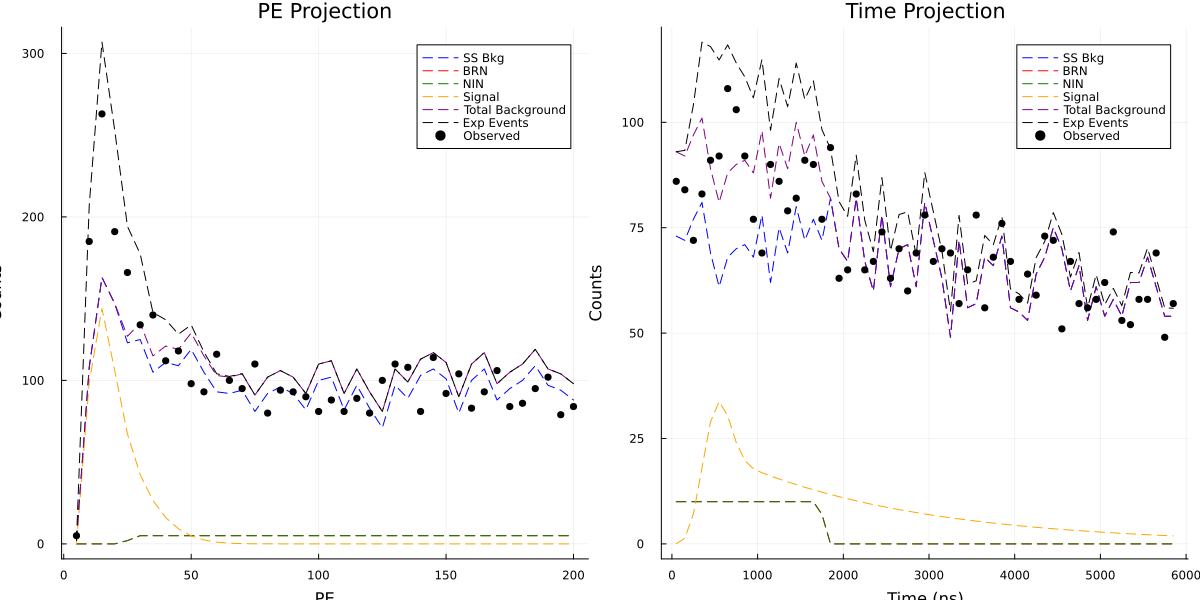

In [3]:

# Configure the COHERENT_CSI experiment
coherent_csi = Newtrinos.coherent_csi.configure()

# Access the configured components
physics = coherent_csi.physics
params = Newtrinos.get_params(coherent_csi)
assets = coherent_csi.assets

# Compute the expected signal and backgrounds
signal = Newtrinos.coherent_csi.get_expected(params, physics, assets)  # (n_out, n_time)
brn, nin, ssBkg = Newtrinos.coherent_csi.get_backgrounds(params, assets)  # (n_out, n_time)
total_bkg = brn .+ nin .+ ssBkg  # (n_out, n_time)
exp_events = signal .+ total_bkg  # (n_out, n_time)

# Observed data
observed = assets.observed  # (n_out, n_time)

# Compute projections
PE_bins = assets.out_centers
time_bins = assets.time_bins

# PE projection: sum over time bins
signal_PE = sum(signal, dims=2)[:, 1]
brn_PE = sum(brn, dims=2)[:, 1]
nin_PE = sum(nin, dims=2)[:, 1]
ssBkg_PE = sum(ssBkg, dims=2)[:, 1]
total_bkg_PE = sum(total_bkg, dims=2)[:, 1]
exp_events_PE = sum(exp_events, dims=2)[:, 1]
observed_PE = sum(observed, dims=2)[:, 1]

# Time projection: sum over PE bins
signal_time = sum(signal, dims=1)[1, :]
brn_time = sum(brn, dims=1)[1, :]
nin_time = sum(nin, dims=1)[1, :]
ssBkg_time = sum(ssBkg, dims=1)[1, :]
total_bkg_time = sum(total_bkg, dims=1)[1, :]
exp_events_time = sum(exp_events, dims=1)[1, :]
observed_time = sum(observed, dims=1)[1, :]

# Print total counts
println("Total signal counts: ", sum(signal))
println("Total BRN background counts: ", sum(brn))
println("Total NIN counts: ", sum(nin))
println("Total SS background counts: ", sum(ssBkg))
println("Total observed counts: ", sum(observed))

# Create the (1, 2) subplot layout
plot1 = plot(PE_bins, ssBkg_PE; label="SS Bkg", linestyle=:dash, color=:blue, xlabel="PE", ylabel="Counts", title="PE Projection")
plot!(PE_bins, brn_PE; label="BRN", linestyle=:dash, color=:red)
plot!(PE_bins, nin_PE; label="NIN", linestyle=:dash, color=:green)
plot!(PE_bins, signal_PE; label="Signal", linestyle=:dash, color=:orange)
plot!(PE_bins, total_bkg_PE; label="Total Background", linestyle=:dash, color=:purple)
plot!(PE_bins, exp_events_PE; label="Exp Events", linestyle=:dash, color=:black)
scatter!(PE_bins, observed_PE; label="Observed", color=:black)

plot2 = plot(time_bins, ssBkg_time; label="SS Bkg", linestyle=:dash, color=:blue, xlabel="Time (ns)", ylabel="Counts", title="Time Projection")
plot!(time_bins, brn_time; label="BRN", linestyle=:dash, color=:red)
plot!(time_bins, nin_time; label="NIN", linestyle=:dash, color=:green)
plot!(time_bins, signal_time; label="Signal", linestyle=:dash, color=:orange)
plot!(time_bins, total_bkg_time; label="Total Background", linestyle=:dash, color=:purple)
plot!(time_bins, exp_events_time; label="Exp Events", linestyle=:dash, color=:black)
scatter!(time_bins, observed_time; label="Observed", color=:black)

# Combine the two plots into a single layout
plot(plot1, plot2, layout=(1, 2), size=(1200, 600))

**Test l-Ar Dataset and Prediction**

┌ Info: Loading coherent lAr data
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:86


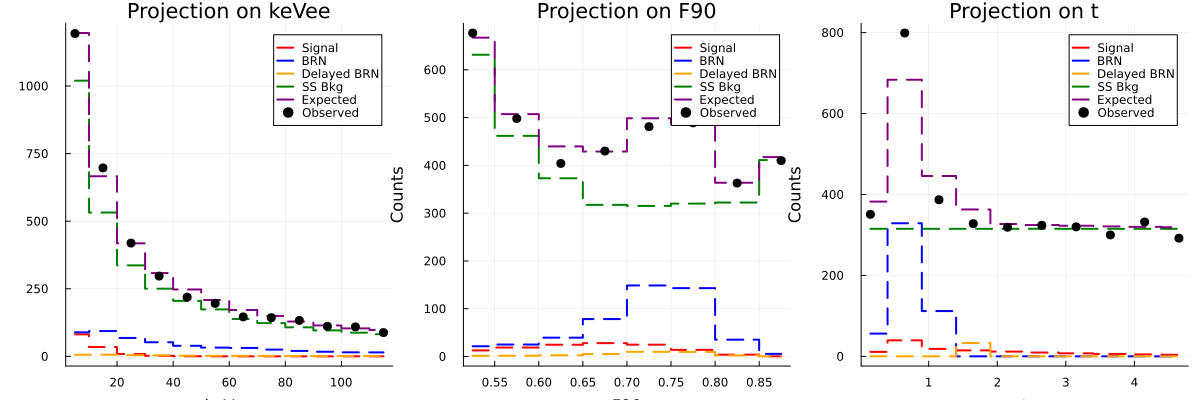

Total signal counts: 127.11966586590307
Total BRN background counts: 496.99999307
Total Delayed BRN background counts: 33.00001642
Total SS background counts: 3152.0001600000032
Total observed counts: 3752


In [4]:
# Configure the COHERENT_lAr experiment
coherent_lAr = Newtrinos.coherent_lAr.configure()

# Access the configured components
physics = coherent_lAr.physics
params = Newtrinos.get_params(coherent_lAr)
assets = coherent_lAr.assets

# Signal and Backgrounds
expected_counts = Newtrinos.coherent_lAr.get_expected(params, physics, assets)
bkg_brn, bkg_delbrn, bkg_ss_bkg = Newtrinos.coherent_lAr.get_backgrounds(params, assets)
signal_cum = bkg_brn .+ bkg_delbrn .+ bkg_ss_bkg .+ expected_counts

# Observed data
observed_counts = assets.observed

# Define the second subplot matrix: Projections on keVee, F90, and t
# Projections are computed by summing over the appropriate bins
keVee_centers = assets.out_centers
f90_centers = assets.f90_centers
timing_centers = assets.timing_centers

# Reshape the signal and background arrays to match the binning structure
n_keVee_bins = length(keVee_centers)
n_f90_bins = length(f90_centers)
n_timing_bins = length(timing_centers)
# Print total counts
println("Total signal counts: ", sum(expected_counts))
println("Total BRN background counts: ", sum(bkg_brn))
println("Total Delayed BRN background counts: ", sum(bkg_delbrn))
println("Total SS background counts: ", sum(bkg_ss_bkg))
println("Total observed counts: ", sum(observed_counts))

# Stack the bin centers and counts into separate arrays for each component
data_signal = hcat(repeat(keVee_centers, inner=n_f90_bins * n_timing_bins),
                   repeat(f90_centers, inner=n_timing_bins, outer=n_keVee_bins),
                   repeat(timing_centers, outer=n_keVee_bins * n_f90_bins),
                   expected_counts)

data_expected = hcat(repeat(keVee_centers, inner=n_f90_bins * n_timing_bins),
                      repeat(f90_centers, inner=n_timing_bins, outer=n_keVee_bins),
                      repeat(timing_centers, outer=n_keVee_bins * n_f90_bins),
                      signal_cum)

data_brn = hcat(repeat(keVee_centers, inner=n_f90_bins * n_timing_bins),
                repeat(f90_centers, inner=n_timing_bins, outer=n_keVee_bins),
                repeat(timing_centers, outer=n_keVee_bins * n_f90_bins),
                bkg_brn)

data_delbrn = hcat(repeat(keVee_centers, inner=n_f90_bins * n_timing_bins),
                   repeat(f90_centers, inner=n_timing_bins, outer=n_keVee_bins),
                   repeat(timing_centers, outer=n_keVee_bins * n_f90_bins),
                   bkg_delbrn)

data_ss_bkg = hcat(repeat(keVee_centers, inner=n_f90_bins * n_timing_bins),
                   repeat(f90_centers, inner=n_timing_bins, outer=n_keVee_bins),
                   repeat(timing_centers, outer=n_keVee_bins * n_f90_bins),
                   bkg_ss_bkg)

data_observed = hcat(repeat(keVee_centers, inner=n_f90_bins * n_timing_bins),
                     repeat(f90_centers, inner=n_timing_bins, outer=n_keVee_bins),
                     repeat(timing_centers, outer=n_keVee_bins * n_f90_bins),
                     observed_counts)

# Function to compute projections
function compute_projection(data, bin_centers, col_index)
    proj = zeros(length(bin_centers))
    for i in 1:length(bin_centers)
        proj[i] = sum(data[data[:, col_index] .== bin_centers[i], 4])
    end
    return proj
end

# Compute projections for each component
proj_keVee_signal = compute_projection(data_signal, keVee_centers, 1)
proj_keVee_brn = compute_projection(data_brn, keVee_centers, 1)
proj_keVee_delbrn = compute_projection(data_delbrn, keVee_centers, 1)
proj_keVee_ss_bkg = compute_projection(data_ss_bkg, keVee_centers, 1)
proj_keVee_observed = compute_projection(data_observed, keVee_centers, 1)
proj_keVee_expected = compute_projection(data_expected, keVee_centers, 1)

proj_F90_signal = compute_projection(data_signal, f90_centers, 2)
proj_F90_brn = compute_projection(data_brn, f90_centers, 2)
proj_F90_delbrn = compute_projection(data_delbrn, f90_centers, 2)
proj_F90_ss_bkg = compute_projection(data_ss_bkg, f90_centers, 2)
proj_F90_observed = compute_projection(data_observed, f90_centers, 2)
proj_F90_expected = compute_projection(data_expected, f90_centers, 2)

proj_t_signal = compute_projection(data_signal, timing_centers, 3)
proj_t_brn = compute_projection(data_brn, timing_centers, 3)
proj_t_delbrn = compute_projection(data_delbrn, timing_centers, 3)
proj_t_ss_bkg = compute_projection(data_ss_bkg, timing_centers, 3)
proj_t_observed = compute_projection(data_observed, timing_centers, 3)
proj_t_expected = compute_projection(data_expected, timing_centers, 3)

# Plot the projections with step-like visualization
plt4 = plot(keVee_centers, proj_keVee_signal, label="Signal", seriestype=:stepmid, color=:red, lw=2, linestyle=:dash, xlabel="keVee", ylabel="Counts", title="Projection on keVee")
plot!(plt4, keVee_centers, proj_keVee_brn, label="BRN", seriestype=:stepmid, color=:blue, lw=2, linestyle=:dash)
plot!(plt4, keVee_centers, proj_keVee_delbrn, label="Delayed BRN", seriestype=:stepmid, color=:orange, lw=2, linestyle=:dash)
plot!(plt4, keVee_centers, proj_keVee_ss_bkg, label="SS Bkg", seriestype=:stepmid, color=:green, lw=2, linestyle=:dash)
plot!(plt4, keVee_centers, proj_keVee_expected, label="Expected", seriestype=:stepmid, color=:purple, lw=2, linestyle=:dash)
plot!(plt4, keVee_centers, proj_keVee_observed, label="Observed", seriestype=:scatter, marker=:circle, markersize=5, color=:black)

plt5 = plot(f90_centers, proj_F90_signal, label="Signal", seriestype=:stepmid, color=:red, lw=2, linestyle=:dash, xlabel="F90", ylabel="Counts", title="Projection on F90")
plot!(plt5, f90_centers, proj_F90_brn, label="BRN", seriestype=:stepmid, color=:blue, lw=2, linestyle=:dash)
plot!(plt5, f90_centers, proj_F90_delbrn, label="Delayed BRN", seriestype=:stepmid, color=:orange, lw=2, linestyle=:dash)
plot!(plt5, f90_centers, proj_F90_ss_bkg, label="SS Bkg", seriestype=:stepmid, color=:green, lw=2, linestyle=:dash)
plot!(plt5, f90_centers, proj_F90_expected, label="Expected", seriestype=:stepmid, color=:purple, lw=2, linestyle=:dash)
plot!(plt5, f90_centers, proj_F90_observed, label="Observed", seriestype=:scatter, marker=:circle, markersize=5, color=:black)

plt6 = plot(timing_centers, proj_t_signal, label="Signal", seriestype=:stepmid, color=:red, lw=2, linestyle=:dash, xlabel="t", ylabel="Counts", title="Projection on t")
plot!(plt6, timing_centers, proj_t_brn, label="BRN", seriestype=:stepmid, color=:blue, lw=2, linestyle=:dash)
plot!(plt6, timing_centers, proj_t_delbrn, label="Delayed BRN", seriestype=:stepmid, color=:orange, lw=2, linestyle=:dash)
plot!(plt6, timing_centers, proj_t_ss_bkg, label="SS Bkg", seriestype=:stepmid, color=:green, lw=2, linestyle=:dash)
plot!(plt6, timing_centers, proj_t_expected, label="Expected", seriestype=:stepmid, color=:purple, lw=2, linestyle=:dash)
plot!(plt6, timing_centers, proj_t_observed, label="Observed", seriestype=:scatter, marker=:circle, markersize=5, color=:black)

# Combine the plots into a single layout
plot(plt4, plt5, plt6, layout=(1,3), size=(1200,400))
display(current())

**Check Parameter Dependence**

┌ Info: Flux is not fully configured yet.
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:194
┌ Info: Loading and binning CsI data
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:124


vals_nom[1:10] = [0.0, 0.013047359179324291, 0.014517892668548322, 0.006332906975814493, 0.001832821926967645, 0.0005112359329669416, 0.00019562825231087506, 0.00010120415666171884, 5.629465784186361e-5, 2.9926390244160823e-5]

┌ Info: Configuring Flux
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:125



sum(vals_nom) = 519.4258117002626
vals_nom[1:10] = [0.0, 0.013047359179324291, 0.014517892668548322, 0.006332906975814493, 0.001832821926967645, 0.0005112359329669416, 0.00019562825231087506, 0.00010120415666171884, 5.629465784186361e-5, 2.9926390244160823e-5]
sum(vals_nom) = 519.4258117002626
vals_nom[1:10] = [0.0, 0.013047359179324291, 0.014517892668548322, 0.006332906975814493, 0.001832821926967645, 0.0005112359329669416, 0.00019562825231087506, 0.00010120415666171884, 5.629465784186361e-5, 2.9926390244160823e-5]
sum(vals_nom) = 519.4258117002626
vals_nom[1:10] = [0.0, 0.013047359179324291, 0.014517892668548322, 0.006332906975814493, 0.001832821926967645, 0.0005112359329669416, 0.00019562825231087506, 0.00010120415666171884, 5.629465784186361e-5, 2.9926390244160823e-5]
sum(vals_nom) = 519.4258117002626


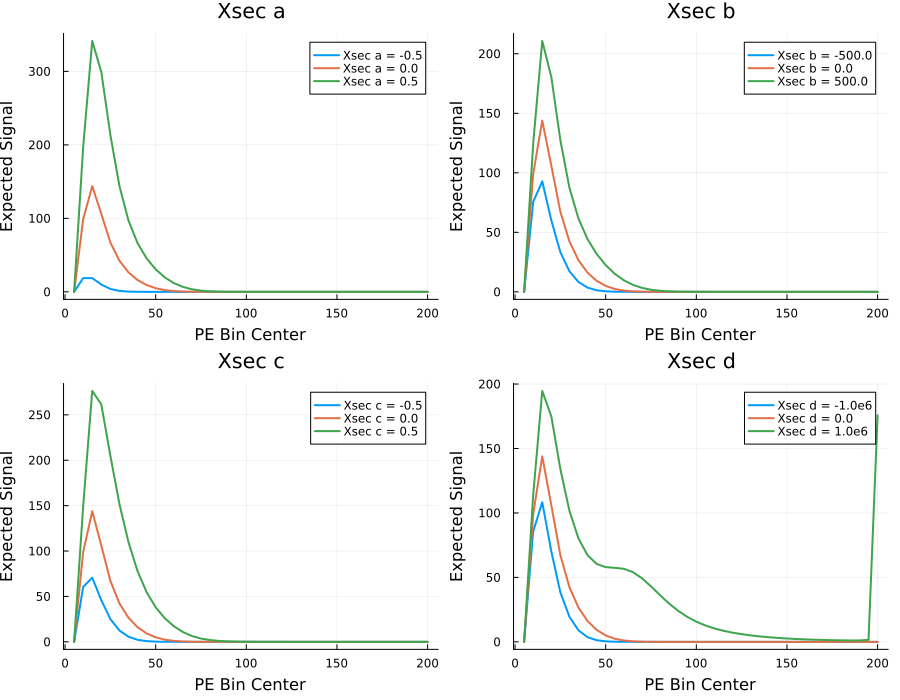

In [5]:
# Check dependence of expected signal PE projection on cevns_xsec parameters (CsI)

coherent_csi = Newtrinos.coherent_csi.configure()
physics = coherent_csi.physics
assets = coherent_csi.assets
p_nom = Newtrinos.get_params(coherent_csi)
out_centers = assets.out_centers

param_syms = [:cevns_xsec_a, :cevns_xsec_b, :cevns_xsec_c, :cevns_xsec_d]
param_labels = ["Xsec a", "Xsec b", "Xsec c", "Xsec d"]
param_scales = [0.5, 5e2, 0.5, 1e6]  # scaling for a, b, c, d

plots = []
for (i, sym) in enumerate(param_syms)
    plt = plot()
    for val in [-1.0, 0.0, 1.0]
        p = deepcopy(p_nom)
        p = merge(p, (sym => val * param_scales[i],))
        vals = Newtrinos.coherent_csi.get_expected(p, physics, assets)
        vals_PE = sum(vals, dims=2)[:, 1]  # Project to PE
        label_str = param_scales[i] == 1 ? "$(param_labels[i]) = $val" : "$(param_labels[i]) = $(val * param_scales[i])"
        plot!(plt, out_centers, vals_PE, label=label_str, lw=2)
    end
    plot!(plt, xlabel="PE Bin Center", ylabel="Expected Signal", title=param_labels[i])
    push!(plots, plt)
    vals_nom = Newtrinos.coherent_csi.get_expected(p_nom, physics, assets)
    @show vals_nom[1:10]
    @show sum(vals_nom)
end
plot(plots..., layout=(2,2), size=(900,700))

expected_counts_nom[1:10] = [0.7134986829631883, 2.561116392778422, 1.2038711515239096, 0.9558205498340436, 0.7639001848830121, 0.6106604027315748, 0.4882343952139328, 0.388273913149741, 0.3082100658036578, 0.24600292767520784]

┌ Info: Loading coherent lAr data
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:86



sum(expected_counts_nom) = 127.11966586590307
expected_counts_nom[1:10] = [0.7134986829631883, 2.561116392778422, 1.2038711515239096, 0.9558205498340436, 0.7639001848830121, 0.6106604027315748, 0.4882343952139328, 0.388273913149741, 0.3082100658036578, 0.24600292767520784]
sum(expected_counts_nom) = 127.11966586590307
expected_counts_nom[1:10] = [0.7134986829631883, 2.561116392778422, 1.2038711515239096, 0.9558205498340436, 0.7639001848830121, 0.6106604027315748, 0.4882343952139328, 0.388273913149741, 0.3082100658036578, 0.24600292767520784]
sum(expected_counts_nom) = 127.11966586590307
expected_counts_nom[1:10] = [0.7134986829631883, 2.561116392778422, 1.2038711515239096, 0.9558205498340436, 0.7639001848830121, 0.6106604027315748, 0.4882343952139328, 0.388273913149741, 0.3082100658036578, 0.24600292767520784]
sum(expected_counts_nom) = 127.11966586590307


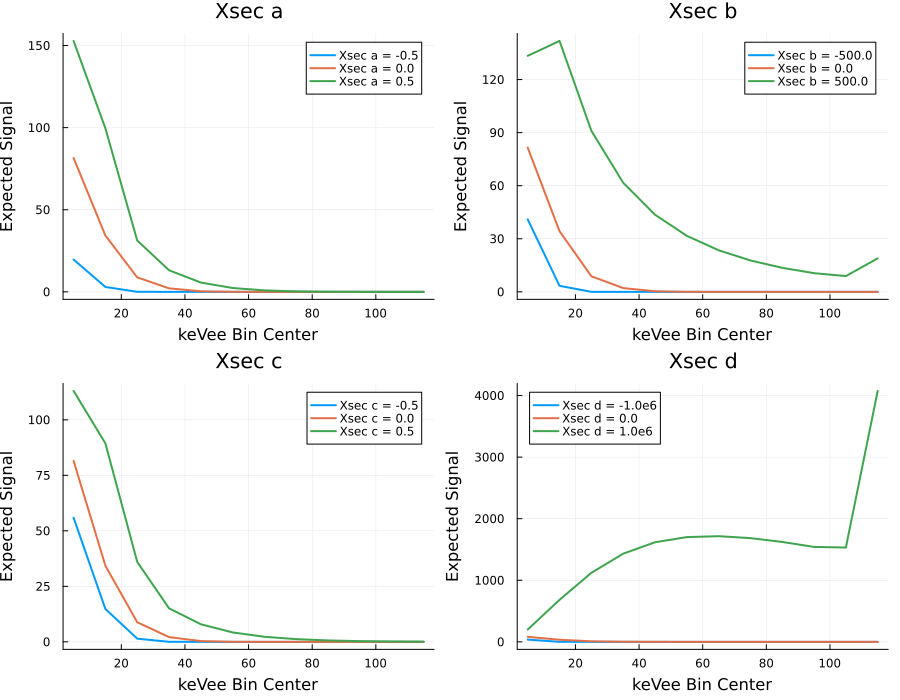

In [6]:
# Check dependence of expected signal PE projection on cevns_xsec parameters (l-Ar)

coherent_lAr = Newtrinos.coherent_lAr.configure()
physics = coherent_lAr.physics
assets = coherent_lAr.assets
p_nom = Newtrinos.get_params(coherent_lAr)
keVee_centers = assets.out_centers
f90_centers = assets.f90_centers
timing_centers = assets.timing_centers

n_keVee_bins = length(keVee_centers)
n_f90_bins = length(f90_centers)
n_timing_bins = length(timing_centers)

function compute_projection(data, bin_centers, col_index)
    proj = zeros(length(bin_centers))
    for i in 1:length(bin_centers)
        proj[i] = sum(data[data[:, col_index] .== bin_centers[i], 4])
    end
    return proj
end

param_syms = [:cevns_xsec_a, :cevns_xsec_b, :cevns_xsec_c, :cevns_xsec_d]
param_labels = ["Xsec a", "Xsec b", "Xsec c", "Xsec d"]
param_scales = [0.5, 5e2, 0.5, 1e6]

plots = []
for (i, sym) in enumerate(param_syms)
    plt = plot()
    for val in [-1.0, 0.0, 1.0]
        p = deepcopy(p_nom)
        p = merge(p, (sym => val * param_scales[i],))
        expected_counts = Newtrinos.coherent_lAr.get_expected(p, physics, assets)
        data_signal = hcat(
            repeat(keVee_centers, inner=n_f90_bins * n_timing_bins),
            repeat(f90_centers, inner=n_timing_bins, outer=n_keVee_bins),
            repeat(timing_centers, outer=n_keVee_bins * n_f90_bins),
            expected_counts
        )
        proj_keVee_signal = compute_projection(data_signal, keVee_centers, 1)
        label_str = param_scales[i] == 1 ? "$(param_labels[i]) = $val" : "$(param_labels[i]) = $(val * param_scales[i])"
        plot!(plt, keVee_centers, proj_keVee_signal, label=label_str, lw=2)
    end
    plot!(plt, xlabel="keVee Bin Center", ylabel="Expected Signal", title=param_labels[i])
    push!(plots, plt)
    expected_counts_nom = Newtrinos.coherent_lAr.get_expected(p_nom, physics, assets)
    @show expected_counts_nom[1:10]
    @show sum(expected_counts_nom)
end
plot(plots..., layout=(2,2), size=(900,700))

┌ Info: Flux is not fully configured yet.
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:194
┌ Info: Loading and binning CsI data
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:124
┌ Info: Configuring Flux
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:125
┌ Info: Loading coherent lAr data
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:86
┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related 

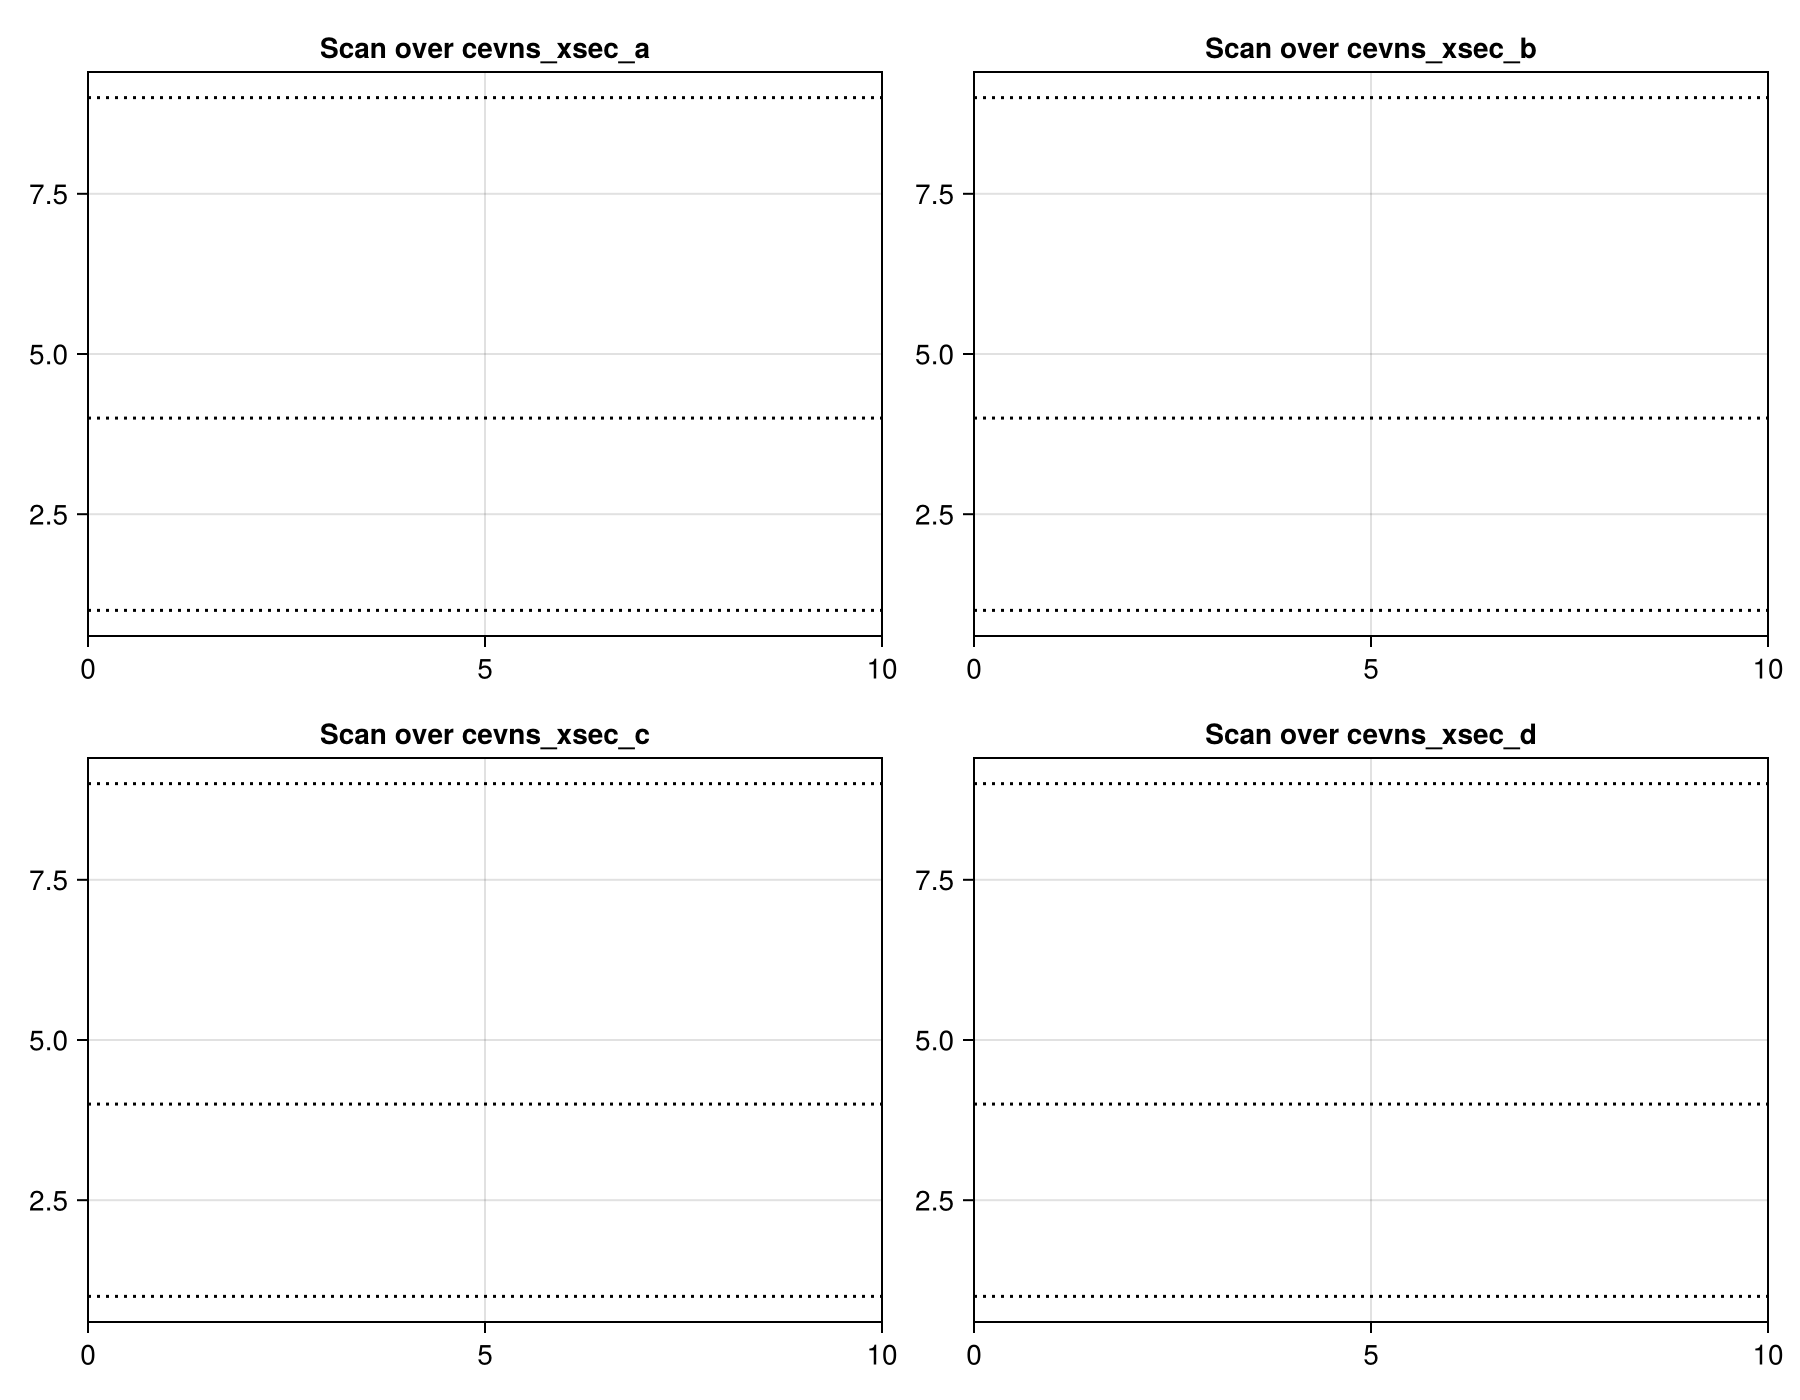

In [7]:
using CairoMakie

coherent_csi = Newtrinos.coherent_csi.configure()
coherent_lAr = Newtrinos.coherent_lAr.configure()
experiments = (; coherent_csi)

likelihood = Newtrinos.generate_likelihood(experiments)
p = Newtrinos.get_params(experiments)
priors = Newtrinos.get_priors(experiments)


scan_params = [
    (:cevns_xsec_a, 100, "Scan over cevns_xsec_a"),
    (:cevns_xsec_b, 100, "Scan over cevns_xsec_b"),
    (:cevns_xsec_c, 100, "Scan over cevns_xsec_c"),
    (:cevns_xsec_d, 100, "Scan over cevns_xsec_d"),
]

fig = Figure(resolution = (900, 700))

for (i, (param, npoints, label)) in enumerate(scan_params)
    row, col = fldmod1(i, 2)   # 2 columns grid
    ax = Axis(fig[row, col], title = label)

    scan_tuple = NamedTuple{(param,)}((npoints,))
    result = Newtrinos.scan(likelihood, priors, scan_tuple, p)

    CairoMakie.plot!(ax, result)  # uses the Newtrinos recipe
end

fig

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/heerakbanerjee/.julia/packages/Makie/aJUtI/src/scenes.jl:259
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


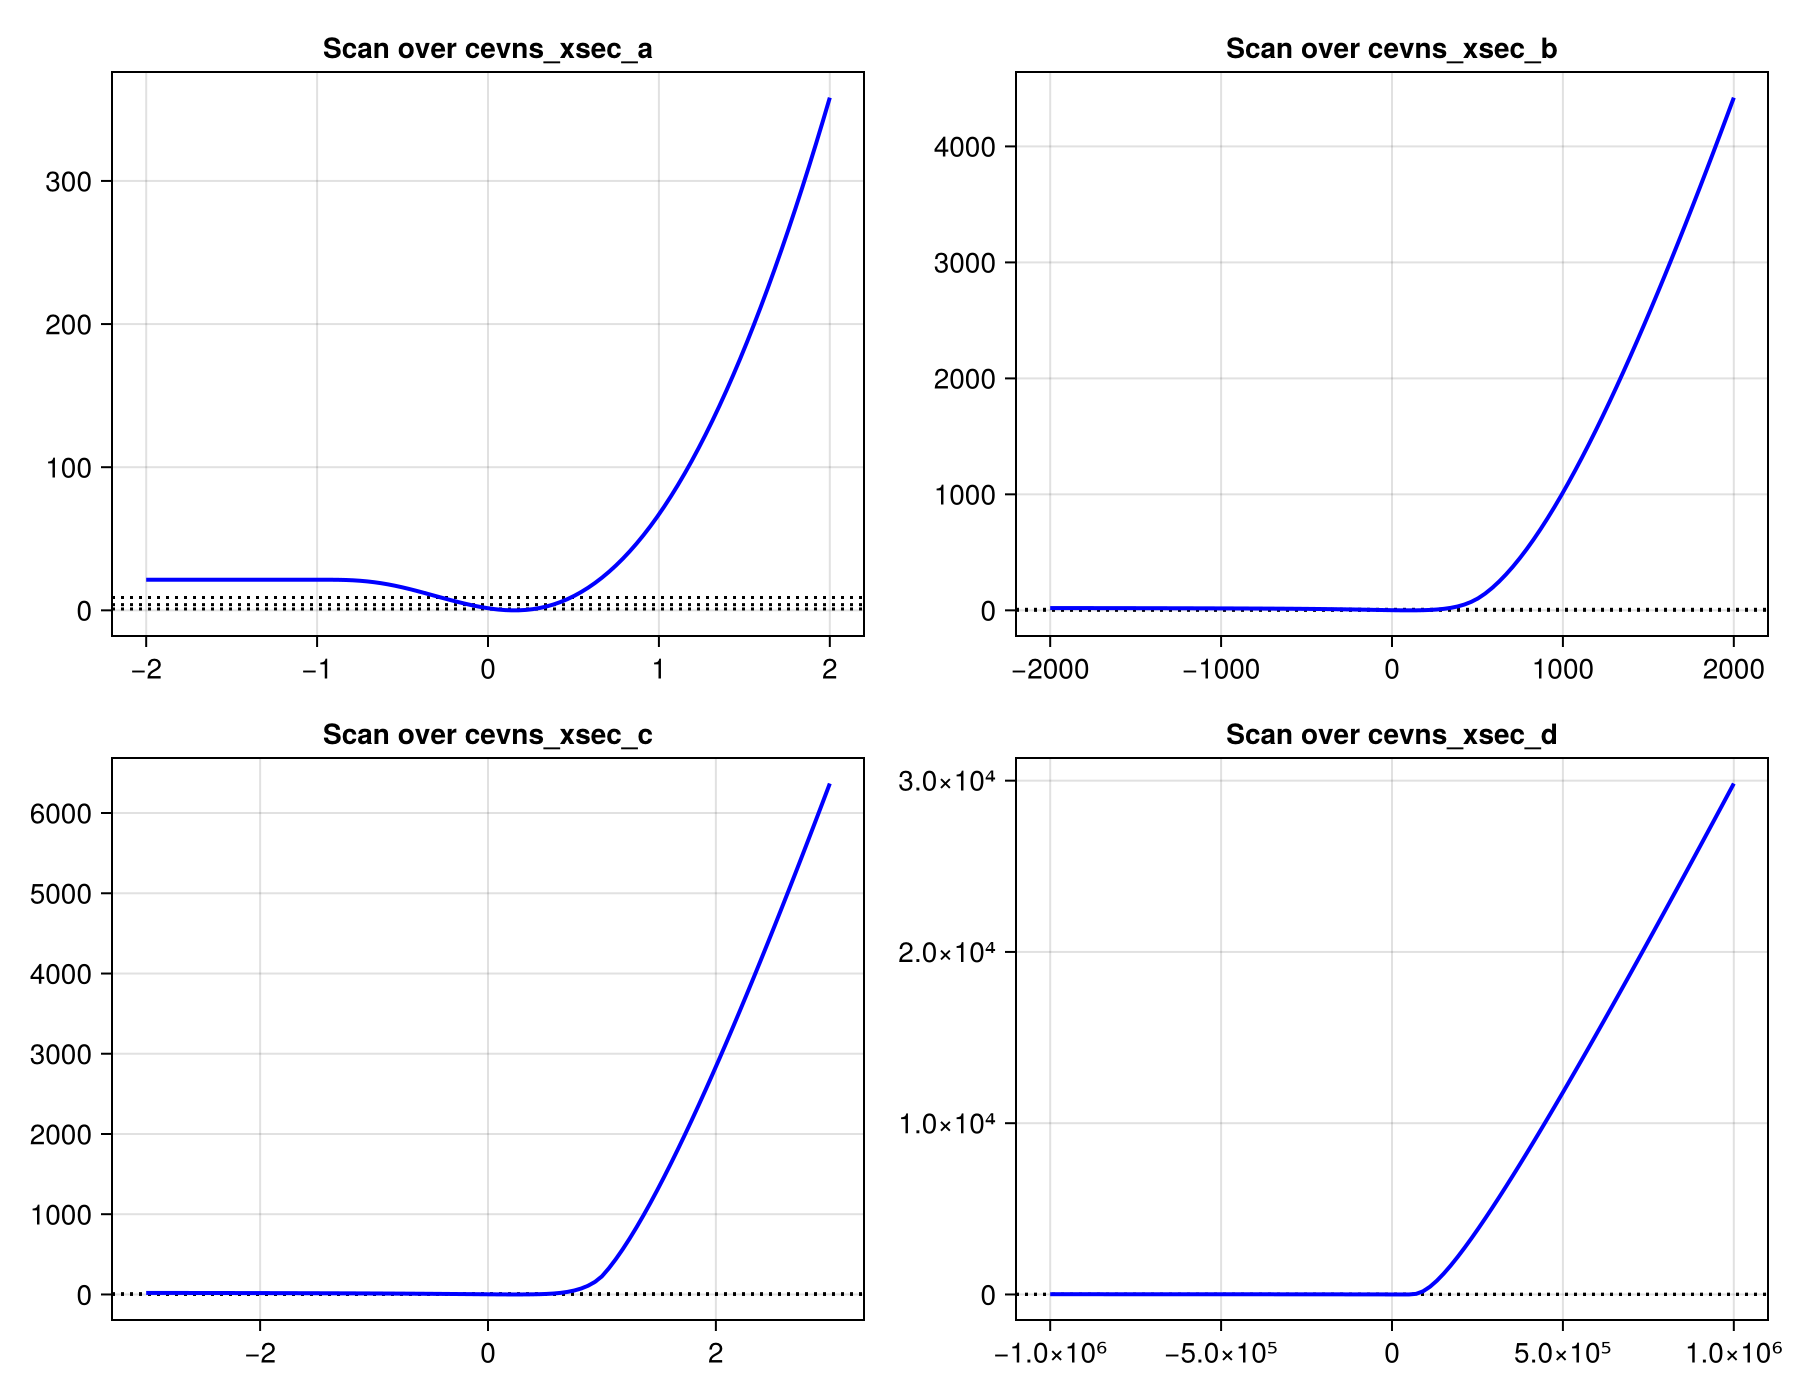

In [8]:
experiments = (; coherent_lAr)

likelihood = Newtrinos.generate_likelihood(experiments)
p = Newtrinos.get_params(experiments)
priors = Newtrinos.get_priors(experiments)


scan_params = [
    (:cevns_xsec_a, 100, "Scan over cevns_xsec_a"),
    (:cevns_xsec_b, 100, "Scan over cevns_xsec_b"),
    (:cevns_xsec_c, 100, "Scan over cevns_xsec_c"),
    (:cevns_xsec_d, 100, "Scan over cevns_xsec_d"),
]

fig = Figure(resolution = (900, 700))

for (i, (param, npoints, label)) in enumerate(scan_params)
    row, col = fldmod1(i, 2)   # 2 columns grid
    ax = Axis(fig[row, col], title = label)

    scan_tuple = NamedTuple{(param,)}((npoints,))
    result = Newtrinos.scan(likelihood, priors, scan_tuple, p)

    CairoMakie.plot!(ax, result)  # uses the Newtrinos recipe
end

fig

In [9]:
coherent_csi = Newtrinos.coherent_csi.configure()
csi_physics = coherent_csi.physics
csi_params = Newtrinos.get_params(coherent_csi)
csi_assets = coherent_csi.assets

coherent_lAr = Newtrinos.coherent_lAr.configure()
lar_physics = coherent_lAr.physics
lAr_params = Newtrinos.get_params(coherent_lAr)
lar_assets = coherent_lAr.assets

csi_exp= Newtrinos.coherent_csi.get_expected(csi_params, csi_physics, csi_assets)
lar_exp= Newtrinos.coherent_lAr.get_expected(lAr_params, lar_physics, lar_assets)

csi_bkg= Newtrinos.coherent_csi.get_backgrounds(csi_params, csi_assets)
lar_bkg= Newtrinos.coherent_lAr.get_backgrounds(lAr_params, lar_assets)

println("CsI prediction shape: ", size(csi_exp))
for b in csi_bkg
    println("CsI background shape: ", size(b))
end
println("CsI Observed shape: ", size(csi_assets.observed))
println("-----------------------------")

println("LAr prediction shape: ", size(lar_exp))
for b in lar_bkg
    println("LAr background shape: ", size(b))
end
println("LAr Observed shape: ", size(lar_assets.observed))

┌ Info: Flux is not fully configured yet.
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:194
┌ Info: Loading and binning CsI data
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:124


CsI prediction shape: (40, 59)
CsI background shape: (40, 59)
CsI background shape: (40, 59)
CsI background shape: (40, 59)
CsI Observed shape: (

┌ Info: Configuring Flux
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:125
┌ Info: Loading coherent lAr data
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:86


40, 59)
-----------------------------
LAr prediction shape: (960,)
LAr background shape: (960,)
LAr background shape: (960,)
LAr background shape: (960,)
LAr Observed shape: (960,)


In [10]:
println("CsI Basis PE bins: ", size(csi_assets.out_centers))
println("CsI Basis Time bins: ", size(csi_assets.time_bins))

CsI Basis PE bins: (40,)
CsI Basis Time bins: (59,)
